# Chapter 5: Implementation and simulation of QEC codes: Framework setup and baseline models
## Simulating QEC codes and decoders with stim

### Simulation 1: minimal simulation of a basic repetition code with stim
The following code snippet shows the minimal source code to simulate a basic repetition code using stim and the pymatching library

In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


```python
import stim
import pymatching
import numpy as np
import matplotlib.pyplot as plt

def sample_repetition_code_mwpm(distance: int = 3, shots: int = 10000) -> None:
    """
    Simulates a repetition code over a range of physical error rates,
    using the pymatching MWPM decoder.
    """
    physical_error_rates = np.linspace(0.01, 0.15, 10)
    logical_error_rates = []

    for p in physical_error_rates:
        # Define the circuit
        circuit = stim.Circuit.generated(
            "repetition_code:memory",
            distance=distance,
            rounds=1,
            before_round_data_depolarization=p
        )
        
        # Sample the circuit to get syndromes and actual observables
        sampler = circuit.compile_detector_sampler()
        syndromes, actual_observables = sampler.sample(shots, separate_observables=True)
        
        # Decode the syndromes using PyMatching
        matcher = pymatching.Matching.from_stim_circuit(circuit)
        predicted_observables = matcher.decode_batch(syndromes)
        
        # Calculate the logical error rate as the cases where the 
        # actual observables differ from the predicted ones
        num_errors = np.sum(predicted_observables != actual_observables)
        logical_error_rates.append(num_errors / shots)

    return physical_error_rates, logical_error_rates


def plot_repetition_code_mwpm_performance(distance: int = 3, shots: int = 10000) -> None:
    """
    Simulates a repetition code over a range of physical error rates,
    decodes using PyMatching, and plots the logical error rate.
    """
    physical_error_rates, logical_error_rates = sample_repetition_code_mwpm(distance, shots)
    # Plotting the results
    plt.figure(figsize=(8, 6))
    plt.plot(physical_error_rates, logical_error_rates, marker='o', label=f'Distance {distance}')
    
    # Reference line to show the break-even point where QEC stops helping
    plt.plot(physical_error_rates, physical_error_rates, linestyle='--', color='gray', label='No QEC')
    plt.title('Repetition Code Performance (Code-Capacity, MWPM Decoder)')
    plt.xlabel('Physical Error Rate (p)')
    plt.ylabel('Logical Error Rate ($p_L$)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

# Execute to input the main parameters
if __name__ == "__main__":
    plot_repetition_code_mwpm_performance(distance=3, shots=10000)
```

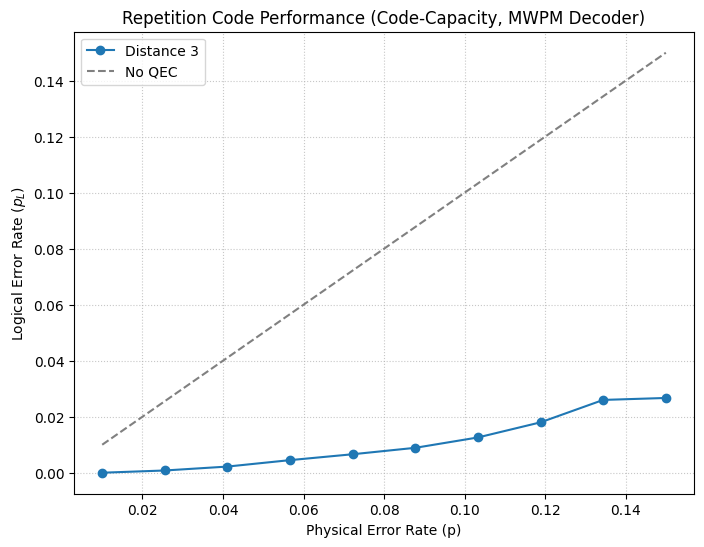

In [7]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

with open('s1_stim_rep_code.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

%run -i 's1_stim_rep_code.py'

plt.savefig('../../figures/stim_rep_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Simulation 2: minimal simulation of a Majority Vote decoder with stim
The following code snippet shows the minimal source code to simulate a basic repetition code using stim and a custom Majority Vote decoder

```python
import stim
import numpy as np
import matplotlib.pyplot as plt
from s2_majority_vote_decoder import decode_batch_majority_vote

def sample_repetition_code_mv(distance: int = 3, shots: int = 10000) -> None:
    """
    Simulates a repetition code over a range of physical error rates,
    decodes using PyMatching, and plots the logical error rate.
    """
    physical_error_rates = np.linspace(0.01, 0.15, 10)
    logical_error_rates = []

    for p in physical_error_rates:
        # Define the circuit
        circuit = stim.Circuit.generated(
            "repetition_code:memory",
            distance=distance,
            rounds=1,
            before_round_data_depolarization=p
        )
        
        # Sample the circuit to get syndromes and actual observables
        sampler = circuit.compile_detector_sampler()
        syndromes, actual_observables = sampler.sample(shots, separate_observables=True)
        # Decode the syndromes using our decoder
        predicted_observables = decode_batch_majority_vote(syndromes, circuit, distance)
        
        # Calculate the logical error rate as the cases where the 
        # actual observables differ from the predicted ones
        num_errors = np.sum(predicted_observables != actual_observables)
        logical_error_rates.append(num_errors / shots)
    return physical_error_rates, logical_error_rates

def plot_repetition_code_mv_performance(distance: int = 3, shots: int = 10000) -> None:
    """
    Simulates and plots a repetition code over a range of physical error rates,
    using the majority vote decoder.
    """
    physical_error_rates, logical_error_rates = sample_repetition_code_mv(distance, shots)

    # Plotting the results
    plt.figure(figsize=(8, 6))
    plt.plot(physical_error_rates, logical_error_rates, marker='o', label=f'Distance {distance}')
    
    # Reference line to show the break-even point where QEC stops helping
    plt.plot(physical_error_rates, physical_error_rates, linestyle='--', color='gray', label='No QEC')
    
    plt.title('Repetition Code Performance (Code-Capacity, Majority Vote Decoder)')
    plt.xlabel('Physical Error Rate (p)')
    plt.ylabel('Logical Error Rate ($p_L$)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

# Execute to input the main parameters
if __name__ == "__main__":
    plot_repetition_code_mv_performance(distance=3, shots=10000)
```

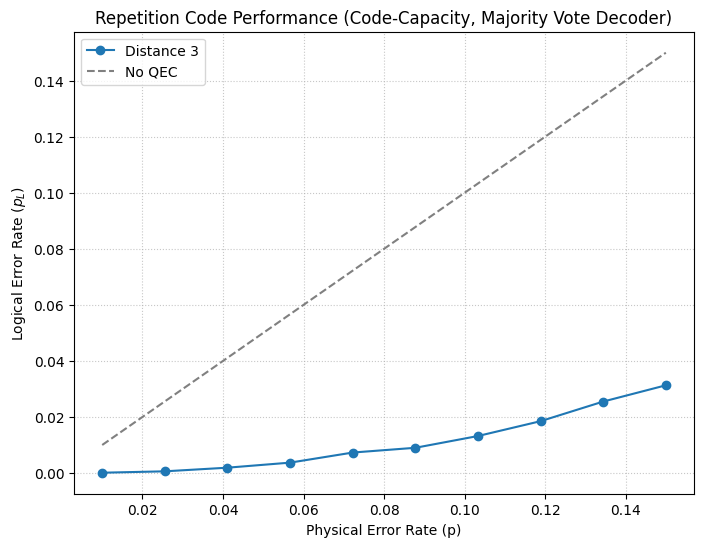

In [8]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

with open('s2_stim_rep_code_majority.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

%run -i 's2_stim_rep_code_majority.py'

plt.savefig('../../figures/stim_rep_vote_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Simulation 3: Comparing MWPM and the Majority Vote decoders
The following code snippet shows the minimal source code to simulate a basic repetition code using the two decoders already implemented

```python
import matplotlib.pyplot as plt
from s1_stim_rep_code import sample_repetition_code_mwpm
from s2_stim_rep_code_majority import sample_repetition_code_mv

def plot_repetition_code_comparison(distance: int = 3, shots: int = 10000) -> None:
    """
    Simulates and plots a repetition code over a range of physical error rates,
    and compares the performance of the majority vote decoder with the MWPM decoder.
    """
    physical_error_rates_mv, logical_error_rates_mv = sample_repetition_code_mv(distance, shots)
    physical_error_rates_mwpm, logical_error_rates_mwpm = sample_repetition_code_mwpm(distance, shots)

    # Plotting the results
    plt.figure(figsize=(8, 6))
    plt.plot(physical_error_rates_mv, logical_error_rates_mv, marker='o', label=f'Majority Vote - Distance {distance}')
    plt.plot(physical_error_rates_mwpm, logical_error_rates_mwpm, marker='s', label=f'MWPM - Distance {distance}')

    # Reference line to show the break-even point where QEC stops helping
    plt.plot(physical_error_rates_mv, physical_error_rates_mv, linestyle='--', color='gray', label='No QEC')
    
    plt.title('Repetition Code Performance (Code-Capacity, Majority Vote Decoder)')
    plt.xlabel('Physical Error Rate (p)')
    plt.ylabel('Logical Error Rate ($p_L$)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

# Execute to input the main parameters
if __name__ == "__main__":
    plot_repetition_code_comparison(distance=3, shots=10000)
```

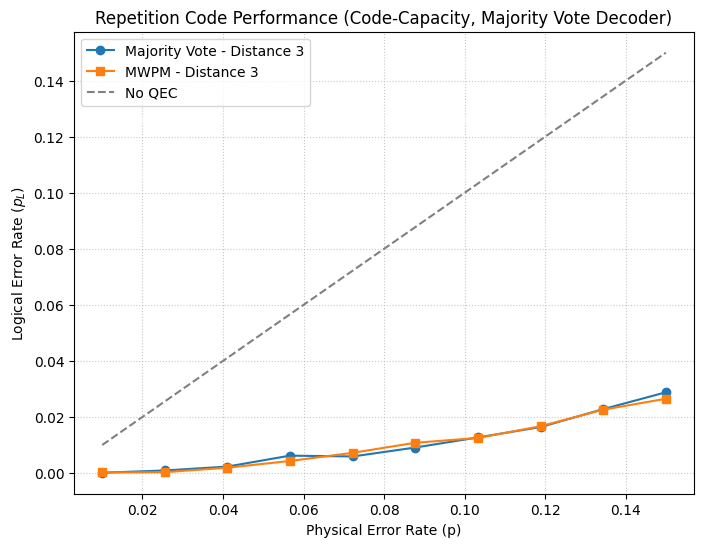

In [9]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

with open('s3_stim_rep_comparison.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

%run -i 's3_stim_rep_comparison.py'

plt.savefig('../../figures/stim_rep_comparison_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Simulation 4: Introducing circuit level and phenomenological noise
The following code snippet shows the necessary changes to introduce more complex noise models

```python
import stim
import numpy as np
from s2_majority_vote_decoder import decode_batch_majority_vote

def sample_repetition_code_mv(distance: int = 3, shots: int = 10000) -> None:
    """
    Simulates a repetition code over a range of physical error rates,
    decodes using PyMatching, and plots the logical error rate.
    """
    physical_error_rates = np.linspace(0.01, 0.15, 10)
    logical_error_rates = []

    for p in physical_error_rates:
        # Define the circuit
        circuit = stim.Circuit.generated(
            "repetition_code:memory",
            distance=distance,
            rounds=1,
            before_round_data_depolarization=p,
            after_clifford_depolarization=p,
            before_measure_flip_probability=p
        )
        
        # Sample the circuit to get syndromes and actual observables
        sampler = circuit.compile_detector_sampler()
        syndromes, actual_observables = sampler.sample(shots, separate_observables=True)
        # Decode the syndromes using our decoder
        predicted_observables = decode_batch_majority_vote(syndromes, circuit, distance)
        
        # Calculate the logical error rate as the cases where the 
        # actual observables differ from the predicted ones
        num_errors = np.sum(predicted_observables != actual_observables)
        logical_error_rates.append(num_errors / shots)
    return physical_error_rates, logical_error_rates
```

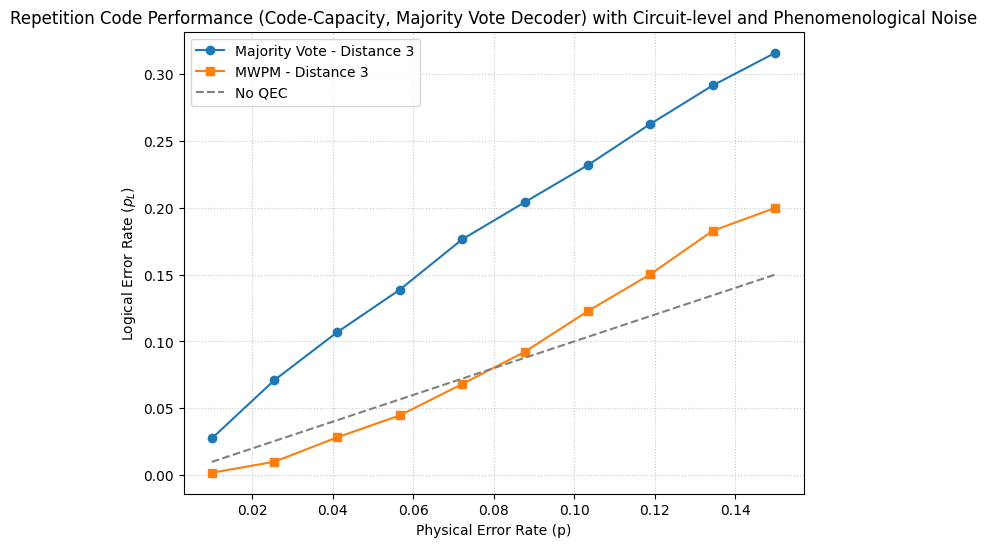

In [11]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

with open('s4_majority_vote_noise.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

%run -i 's4_stim_rep_circuit_noise.py'

plt.savefig('../../figures/stim_rep_circuit_noise_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Simulation 5: Visualizing the impact of code distance
The following code snippet shows the logical error rate for different code distances

In [ ]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt

with open('s5_stim_rep_circuit_distance.py', 'r') as f:
    codigo = f.read()

display(Markdown(f"```python\n{codigo}\n```"))

%run -i 's5_stim_rep_circuit_distance.py'

plt.savefig('../../figures/stim_rep_circuit_distance_plot.png', dpi=300, bbox_inches='tight')
plt.show()